In [3]:
import pandas as pd
import numpy as np
from dython.nominal import associations
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# 'Malgun Gothic' 폰트를 기본으로 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [7]:
df = pd.read_parquet('AB추출.parquet')

In [11]:
na_counts = df.isna().sum()
na_cols = na_counts[na_counts >0]
print(na_cols)

가입통신회사코드            79
직장시도명               17
_2순위신용체크구분         234
최종유효년월_신용_이용         7
RV신청일자             889
연체일자_B0M          1116
OS구분코드             474
혜택수혜율_R3M            9
혜택수혜율_B0M           13
_1순위업종              22
_2순위업종              39
_3순위업종              62
_1순위쇼핑업종            45
_2순위쇼핑업종            71
_3순위쇼핑업종            99
_1순위교통업종           101
_2순위교통업종           216
_3순위교통업종           436
_1순위여유업종           326
_2순위여유업종           636
_3순위여유업종           863
_1순위납부업종           189
_2순위납부업종           550
_3순위납부업종           892
최종카드론_금융상환방식코드     642
최종카드론_신청경로코드       644
최종카드론_대출일자         768
dtype: int64


- 상관계수를 구하기 위해 결측치가 있는 모든 컬럼은 제거한다. 

In [16]:
df = df.dropna(axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Columns: 831 entries, 기준년월 to 이용금액대
dtypes: float64(54), int64(747), object(30)
memory usage: 7.1+ MB


In [20]:
# LabelEncoder 하기

obj_cols = df.select_dtypes(include='object').columns

le_dict = {}

for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116 entries, 0 to 1115
Columns: 831 entries, 기준년월 to 이용금액대
dtypes: float64(54), int32(30), int64(747)
memory usage: 6.9 MB


In [50]:
correlations = df.corr()["Segment"].sort_values(ascending=False)

In [54]:
significant_corr = correlations[correlations.abs() >= 0.3]
significant_corr_sorted = significant_corr.reindex(significant_corr.abs().sort_values(ascending=False).index)

print(significant_corr_sorted)

Segment           1.000000
카드이용한도금액_B1M     -0.653554
카드이용한도금액_B2M     -0.645587
카드이용한도금액         -0.635069
CA한도금액           -0.515938
이용건수_선결제_R6M      0.402885
선결제건수_R6M         0.382041
상환개월수_결제일_R6M    -0.373127
이용건수_선결제_R3M      0.372249
이용금액_선결제_R6M      0.371204
선입금원금_B2M         0.370902
이용횟수_선결제_R6M      0.370574
선입금원금_B0M         0.368353
상환개월수_결제일_R3M    -0.363593
선결제건수_R3M         0.360349
이용금액_선결제_R3M      0.358689
선입금원금_B5M         0.356789
이용개월수_결제일_R6M    -0.351421
이용금액_선결제_B0M      0.344880
이용개월수_결제일_R3M    -0.339004
이용개월수_선결제_R6M     0.334713
이용건수_선결제_B0M      0.327774
이용횟수_선결제_R3M      0.327618
방문일수_앱_R6M        0.313763
홈페이지_선결제건수_R6M    0.305680
방문일수_앱_B0M        0.305060
이용횟수_선결제_B0M      0.300596
Name: Segment, dtype: float64


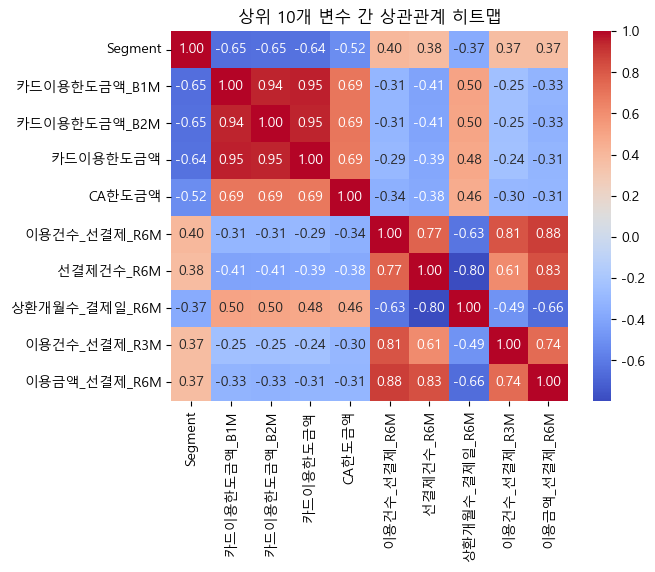

In [34]:
# Segment와 관련 있는 상위 10개 변수만 선택
top_features = correlations.abs().sort_values(ascending=False).head(10).index
sns.heatmap(df[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("상위 10개 변수 간 상관관계 히트맵")
plt.show()